<a href="https://colab.research.google.com/github/pdf1802/f1-data-science/blob/main/notebooks/what_if_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 5 — What-If Simulator
**Notebook:** `what_if_simulator.ipynb`  
**Depends on:** `lap_time_model.pkl`, `overtaking_model.pkl`, `team_encoder.pkl`  
**What it does:** Runs two identical Monte Carlo race simulations with one thing changed between them, then compares the win probability distributions side by side.

> This is the first causal analysis in the project. Modules 1–4 answer *"what will happen?"*  
> Module 5 answers *"what changes if I change X?"* — that's a fundamentally different question.

No model training happens here. This notebook is pure inference + visualisation.

In [1]:
!pip install fastf1 pandas numpy matplotlib plotly xgboost joblib -q

## 1. Setup — Drive, Paths & Model Check

We mount Google Drive to access:
- `f1_cache/` → FastF1 session cache (so we don't re-download qualifying data)
- `f1_models/` → the three `.pkl` files trained in Modules 1 & 2

We print the model directory contents immediately as a **sanity check** —
if the files aren't there, we catch it here instead of getting a cryptic
error 5 cells later.

> `exist_ok=True` makes `makedirs` idempotent — running the cell twice won't crash.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

CACHE_DIR = '/content/drive/MyDrive/f1_cache'
MODEL_DIR  = '/content/drive/MyDrive/f1_models'

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print(f'Cache dir : {CACHE_DIR}')
print(f'Model dir : {MODEL_DIR}')
print()

models_found = os.listdir(MODEL_DIR) if os.path.exists(MODEL_DIR) else []
print(f'Models found: {models_found if models_found else "(empty — check the path)"}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cache dir : /content/drive/MyDrive/f1_cache
Model dir : /content/drive/MyDrive/f1_models

Models found: ['compound_map.json', 'team_encoder.pkl', 'lap_time_model.pkl', 'overtaking_model.pkl']


In [3]:
import os, copy, warnings
import fastf1
import joblib, json
import numpy  as np
import pandas as pd
import matplotlib.pyplot   as plt
import plotly.graph_objects as go
import plotly.express       as px
from dataclasses import dataclass, field
from typing      import List, Optional, Tuple
from collections import Counter

warnings.filterwarnings('ignore')
fastf1.Cache.enable_cache(CACHE_DIR)

print('All imports OK')

All imports OK


## 3. Load Models

We load all three artefacts produced in earlier modules:

| File | Produced in | What it does here |
|---|---|---|
| `lap_time_model.pkl` | Module 1 | Predicts LapDelta every lap for every driver |
| `overtaking_model.pkl` | Module 2 | Resolves overtake attempts between consecutive cars |
| `team_encoder.pkl` | Module 1 | Converts team name strings → integers the model expects |

`compound_map.json` defines `{SOFT:0, MEDIUM:1, HARD:2}` — the single source  
of truth for compound encoding used everywhere.

> **Why load once here and not inside functions?**  
> Loading a `.pkl` file takes ~0.3s. If we called `joblib.load()` inside  
> `simulate_race()`, we'd pay that cost 1000× during Monte Carlo. Loading  
> at module level means we pay it once.

## Constants & Shared Utilities

These three functions are copied verbatim from Module 4.
In the final repo they live in `tools/shared.py` and are imported —
not copy-pasted. For now we keep the notebook self-contained.

`BASE_LAPTIME = 95.0s` — Bahrain 2024 average racing lap.
The model predicts a *delta* from this baseline, not an absolute time.
Adding them together gives us a realistic lap time in seconds.

`PIT_COST = 23.5s` — the time lost by stopping under green flag conditions.
This was measured from FastF1 pit data across 2022–2024 Bahrain races.

In [4]:
#Load models
LAP_MODEL= joblib.load(f'{MODEL_DIR}/lap_time_model.pkl')
OVT_MODEL= joblib.load(f'{MODEL_DIR}/overtaking_model.pkl')
TEAM_ENCODER= joblib.load(f'{MODEL_DIR}/team_encoder.pkl')

with open(f'{MODEL_DIR}/compound_map.json') as f:
    COMPOUND_MAP = json.load(f)
COMPOUND_NAMES= {v: k for k, v in COMPOUND_MAP.items()}

print('Models loaded')
print(f'Lap model: {type(LAP_MODEL).__name__}')
print(f'Overtake model: {type(OVT_MODEL).__name__}')
print(f'Compounds: {COMPOUND_MAP}')

#Global constants
BASE_LAPTIME=95.0 # Bahrain 2024 average racing lap ~95s
PIT_COST_DEFAULT = 23.5   # seconds lost vs staying out (green flag)
PIT_COST_SC      = 17.0   # Safety Car pit
NOISE_STD        = 0.15   # ±0.15s Gaussian noise per lap per driver



#Encoding helpers
def encode_team(team_name: str) -> int:
  try:
    return int(TEAM_ENCODER.transform([team_name])[0])
  except:
    return 0

def encode_compound(name: str) -> int:
  return COMPOUND_MAP.get(name.upper(),1) #default MEDIUM if unknown

# Sanity check
print('\nTeam encoder check:')
for t in ['Red Bull Racing', 'Ferrari', 'Mercedes', 'McLaren']:
    print(f'  {t:<25} → {encode_team(t)}')

Models loaded
Lap model: XGBRegressor
Overtake model: XGBClassifier
Compounds: {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2}

Team encoder check:
  Red Bull Racing           → 11
  Ferrari                   → 4
  Mercedes                  → 8
  McLaren                   → 7


## 4. Simulation Engine (from Module 4)

These four functions are the engine. They are **identical to Module 4** —
we don't retrain or modify anything. We import the logic, not the models.

| Function | What it does |
|---|---|
| `predict_lap_time_batch()` | Calls Module 1 for all active drivers in one shot. `add_noise=True` makes each Monte Carlo run diverge slightly — that's how you get a distribution instead of a single answer. |
| `apply_pit_stop()` | Checks if a driver pits this lap. If yes, resets tyre age to 1 and charges the pit time cost. |
| `check_overtakes()` | Sorts drivers by cumulative race time, checks DRS window (≤1s gap), calls Module 2 to resolve. Max 1 position gain per driver per lap. |
| `simulate_race()` | Runs one full race: lap loop → pit checks → lap time prediction → safety car → overtake resolution. Returns finishing order. |

> `deepcopy(grid)` at the top of `simulate_race()` is critical — without it,
> all 1000 Monte Carlo runs would mutate the same driver objects and produce
> identical results.

In [23]:
# DriverState
@dataclass
class DriverState:
    driver:       str
    team_encoded: int
    team_name:    str
    position:     int
    compound:     int
    tyre_age:     int
    race_time:    float = 0.0
    laps_done:    int   = 0
    retired:      bool  = False
    strategy:     List[Tuple[int, int]] = field(default_factory=list)

    def next_pit(self) -> Optional[Tuple[int, int]]:
        """Returns next scheduled (pit_lap, new_compound), or None."""
        upcoming = [(lap, comp) for lap, comp in self.strategy if lap > self.laps_done]
        return upcoming[0] if upcoming else None

    def __repr__(self):
        cname = COMPOUND_NAMES.get(self.compound, '?')
        return f'P{self.position} {self.driver} | {cname} age {self.tyre_age}'


# Lap time prediction
def predict_lap_time_batch(drivers, lap, config, add_noise=True):
    active = [d for d in drivers if not d.retired]
    if not active:
        return {}
    rows = [{
        'CompoundEncoded' : d.compound,
        'TyreLife'        : d.tyre_age,
        'TeamEncoded'     : d.team_encoded,
        'LapNumber'       : lap,
        'TrackTemp'       : config['track_temp'],
        'AirTemp'         : config['air_temp'],
        'RainfallEncoded' : config['rainfall'],
    } for d in active]
    features = pd.DataFrame(rows)
    deltas   = LAP_MODEL.predict(features)
    factors  = np.array([config['pace_factors'].get(d.team_name, 1.02) for d in active])
    noise    = np.random.normal(0, NOISE_STD, len(active)) if add_noise else 0
    times    = BASE_LAPTIME + deltas + (factors - 1.0) * BASE_LAPTIME + noise
    return {d.driver: t for d, t in zip(active, times)}


# Pit stop logic
def apply_pit_stop(driver, lap, sc_active=False):
    next_stop = driver.next_pit()
    if next_stop is None or next_stop[0] != lap:
        return False, 0.0
    driver.compound = next_stop[1]
    driver.tyre_age = 1
    cost = PIT_COST_SC if sc_active else PIT_COST_DEFAULT
    return True, np.random.normal(cost, 0.8)


# Overtake resolution
DRS_WINDOW = 1.0

def check_overtakes(drivers):
    pace_order = sorted(drivers, key=lambda d: d.race_time)
    for i in range(1, len(pace_order)):
        behind = pace_order[i]
        ahead  = pace_order[i - 1]
        if behind.retired or ahead.retired:
            continue
        gap = behind.race_time - ahead.race_time
        if gap > DRS_WINDOW:
            continue
        # Reorder the features to match the model's expected order
        feats = pd.DataFrame([
            {
                'GapAhead': gap,
                'TyreDelta': ahead.tyre_age - behind.tyre_age,
                'CompoundEncoded': behind.compound, # Added
                'CompoundAheadEncoded': ahead.compound, # Added
                'TyreLife': behind.tyre_age, # Added
                'TyreLifeAhead': ahead.tyre_age,
                'LapNumber': behind.laps_done,
                'Position': behind.position,
            }
        ])
        prob = OVT_MODEL.predict_proba(feats)[0][1]
        if np.random.random() < prob:
            behind.position, ahead.position = ahead.position, behind.position
    return sorted(pace_order, key=lambda d: d.race_time)


# Single race simulation
def simulate_race(config, grid):
    drivers           = copy.deepcopy(grid)
    sc_active         = False
    sc_laps_remaining = 0

    for lap in range(1, config['total_laps'] + 1):
        if sc_active:
            sc_laps_remaining -= 1
            if sc_laps_remaining <= 0:
                sc_active = False
        elif np.random.random() < config['sc_prob_per_lap']:
            sc_active         = True
            sc_laps_remaining = 4

        lap_times = predict_lap_time_batch(drivers, lap, config)

        for driver in drivers:
            if driver.retired:
                continue
            did_pit, pit_cost = apply_pit_stop(driver, lap, sc_active)
            lap_t             = lap_times.get(driver.driver, BASE_LAPTIME + 1.0)
            driver.race_time += lap_t + pit_cost
            driver.tyre_age  += 1
            driver.laps_done += 1

        drivers = check_overtakes(drivers)

    return sorted(drivers, key=lambda d: d.race_time)


print(' Simulation engine defined')


 Simulation engine defined


##  Monte Carlo Wrapper
Runs simulate_race() N times and counts who wins each run.
Divides by N to get win probability per driver.
This is the engine both scenarios share — we call it twice in compare_scenarios().

In [24]:
def monte_carlo(config: dict, grid: list, n_runs: int = 1000) -> dict:
    """
    Run simulate_race() n_runs times and return win probabilities.
    Returns {driver_code: win_probability}, sorted highest first.

    Why Counter and not a dict?
    Counter gives you .most_common() for free — already sorted descending.
    No manual sorting needed.

    Why divide by n_runs at the end instead of inside the loop?
    Dividing once at the end is faster and avoids floating point
    accumulation errors from adding 0.001 a thousand times.
    """
    win_counts = Counter()

    for i in range(n_runs):
        result = simulate_race(config, grid)
        win_counts[result[0].driver] += 1
        if (i + 1) % 200 == 0:
            print(f'  {i + 1}/{n_runs} sims done...')

    return {driver: count / n_runs
            for driver, count in win_counts.most_common()}


print('monte_carlo() defined')

monte_carlo() defined


## 5. Scenario Configuration
Here we define the two scenarios we want to compare.
Everything that stays the same between A and B lives in a shared base config.
Only the one thing we're testing changes.

We validate Bahrain 2023 Round 1 — Verstappen (MEDIUM) vs Perez (SOFT) start.
This is a real strategy split we can cross-check against actual results.

In [25]:
import fastf1

SEASON=2023
ROUND_NUM=1

BASE_CONFIG= {
    'circuit' :' Bahrain 2023',
    'total_laps': 57,
    'track_temp' : 37.0,
    'air_temp' : 29.0,
    'rainfall':0,
    'sc_prob_per_lap':0.04,
}

#Load real qualifying grid
session= fastf1.get_session(SEASON, ROUND_NUM, 'Q')
session.load(telemetry=False,laps=False,weather=False)
results= (session.results
                  .sort_values('Position')
                  .head(6)
                  .reset_index(drop=True)
                  )

print("Qualifyin top 6:")
print(results[['Position','Abbreviation','TeamName']].to_string(index=False))

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
DEBUG:fastf1.ergast:Failed to parse timestamp '' in Ergastresponse.
DEBUG:fastf1.ergast:Failed to parse timestamp '' in Ergastresponse.
req            INFO 	Using cached data for race_control_messages
INFO:fastf1.fastf1.req:Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '55', '14', '63', '44', '18', '31', '27', '4', '77', '24', '22', '23', '2', '20', '81', '21', '10']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['1', '11', '16', '55', '14', '63', '44', '18', '31', '27', '4', '77', '24', '22', '23', '2', '20', '81', 

Qualifyin top 6:
 Position Abbreviation        TeamName
      1.0          VER Red Bull Racing
      2.0          PER Red Bull Racing
      3.0          LEC         Ferrari
      4.0          SAI         Ferrari
      5.0          ALO    Aston Martin
      6.0          RUS        Mercedes


## 6. Pace Factors + Build Both Grids
Pace factors tell the simulator how fast each team's car is relative to the fastest.
We derive them from the first 5 races of the same season so they're data-driven,
not guessed.

Then we build two grids — identical except for VER's starting compound.
Scenario A: VER starts MEDIUM (what actually happened)
Scenario B: VER starts SOFT  (the counterfactual)

In [26]:
def calculate_pace_factors(season: int, n_races: int = 5) -> dict:
    team_times  = {}
    team_counts = {}
    for round_num in range(1, n_races + 1):
        try:
            s    = fastf1.get_session(season, round_num, 'R')
            s.load(telemetry=False)
            laps = s.laps.pick_quicklaps()
            laps = laps[laps['LapTime'].notna()]
            avgs = laps.groupby('Team')['LapTime'].mean().dt.total_seconds()
            for team, t in avgs.items():
                team_times[team]  = team_times.get(team, 0) + t
                team_counts[team] = team_counts.get(team, 0) + 1
        except Exception as e:
            print(f'  Round {round_num} skipped: {e}')

    averages   = {t: team_times[t] / team_counts[t] for t in team_times}
    fastest    = min(averages.values())
    return {t: v / fastest for t, v in sorted(averages.items(), key=lambda x: x[1])}


print(f'Loading {SEASON} pace factors...')
pace_factors = calculate_pace_factors(SEASON, n_races=5)

print(f'\n{SEASON} pace factors:')
for team, f in pace_factors.items():
    print(f'  {team:<25} {f:.4f}  (+{(f-1)*95:.2f}s/lap)')

# Attach pace factors to base config
BASE_CONFIG['pace_factors'] = pace_factors

# Build base grid entries from qualifying
SOFT, MEDIUM, HARD = 0, 1, 2

base_grid = []
for _, row in results.iterrows():
    base_grid.append({
        'driver'   : row['Abbreviation'],
        'team'     : row['TeamName'],
        'position' : int(row['Position']),
        'compound' : MEDIUM,   # default — we override VER below
        'tyre_age' : 1,
    })

# Auto-generate 1-stop strategies for every driver
pit_lap = int(BASE_CONFIG['total_laps'] * 0.40)   # ~lap 23 for Bahrain

def build_strategies(grid, pit_lap):
    return {
        entry['driver']: [(pit_lap, MEDIUM)]
        for entry in grid
    }

STRATEGIES = build_strategies(base_grid, pit_lap)

print(f'\nBase grid built — {len(base_grid)} drivers')
print(f'Pit lap: {pit_lap}')


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data


Loading 2023 pace factors...


core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req            INFO 	Using cached data for weather_data
INFO:fastf1.fastf1.req:Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
INFO:fastf1.fastf1.req:Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Saudi Arabian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Usin


2023 pace factors:
  Red Bull Racing           1.0000  (+0.00s/lap)
  Aston Martin              1.0065  (+0.61s/lap)
  Ferrari                   1.0070  (+0.66s/lap)
  Mercedes                  1.0073  (+0.69s/lap)
  Alpine                    1.0109  (+1.04s/lap)
  Haas F1 Team              1.0136  (+1.29s/lap)
  McLaren                   1.0138  (+1.31s/lap)
  AlphaTauri                1.0164  (+1.56s/lap)
  Alfa Romeo                1.0173  (+1.64s/lap)
  Williams                  1.0178  (+1.69s/lap)

Base grid built — 6 drivers
Pit lap: 22


## 7. Construct the Two Scenarios
We deep-copy the base grid for each scenario so they're fully independent.
The only difference: VER's starting compound.

This is the heart of what-if analysis — change one variable, hold everything else constant.

In [27]:
import copy

def build_driver_states(grid, strategies, config):
    """Convert grid dicts → DriverState objects ready for simulate_race()."""
    drivers = []
    for entry in grid:
        ds = DriverState(
            driver       = entry['driver'],
            team_encoded = encode_team(entry['team']),
            team_name    = entry['team'],
            position     = entry['position'],
            compound     = entry['compound'],
            tyre_age     = entry['tyre_age'],
            strategy     = strategies[entry['driver']],
        )
        drivers.append(ds)
    return drivers


# Scenario A: VER starts MEDIUM (reality)
grid_a = copy.deepcopy(base_grid)
for entry in grid_a:
    if entry['driver'] == 'VER':
        entry['compound'] = MEDIUM

CONFIG_A = copy.deepcopy(BASE_CONFIG)
LABEL_A  = 'VER starts MEDIUM (reality)'
driver_states_a = build_driver_states(grid_a, STRATEGIES, CONFIG_A)

# Scenario B: VER starts SOFT (counterfactual)
grid_b = copy.deepcopy(base_grid)
for entry in grid_b:
    if entry['driver'] == 'VER':
        entry['compound'] = SOFT

CONFIG_B = copy.deepcopy(BASE_CONFIG)
LABEL_B  = 'VER starts SOFT (counterfactual)'
driver_states_b = build_driver_states(grid_b, STRATEGIES, CONFIG_B)

# Sanity check
print('Scenario A grid:')
for d in driver_states_a:
    print(f'  {d}')

print('\nScenario B grid:')
for d in driver_states_b:
    print(f'  {d}')


Scenario A grid:
  P1 VER | MEDIUM age 1
  P2 PER | MEDIUM age 1
  P3 LEC | MEDIUM age 1
  P4 SAI | MEDIUM age 1
  P5 ALO | MEDIUM age 1
  P6 RUS | MEDIUM age 1

Scenario B grid:
  P1 VER | SOFT age 1
  P2 PER | MEDIUM age 1
  P3 LEC | MEDIUM age 1
  P4 SAI | MEDIUM age 1
  P5 ALO | MEDIUM age 1
  P6 RUS | MEDIUM age 1


## 8. compare_scenarios() — the What-If engine
Runs monte_carlo() twice — once per scenario — then subtracts win probabilities.

Positive delta = driver benefits when we switch to Scenario B
Negative delta = driver loses

We return everything in one dict so we only need to call this once before plotting.

In [28]:
def compare_scenarios(config_a, grid_a, config_b, grid_b,
                      n=1000, label_a='Scenario A', label_b='Scenario B'):
    print(f'Running {n} sims — {label_a}...')
    probs_a = monte_carlo(config_a, grid_a, n_runs=n)

    print(f'Running {n} sims — {label_b}...')
    probs_b = monte_carlo(config_b, grid_b, n_runs=n)

    all_drivers = set(probs_a) | set(probs_b)
    delta = {
        d: probs_b.get(d, 0.0) - probs_a.get(d, 0.0)
        for d in all_drivers
    }
    delta = dict(sorted(delta.items(), key=lambda x: abs(x[1]), reverse=True))

    return {
        'label_a' : label_a,
        'label_b' : label_b,
        'probs_a' : probs_a,
        'probs_b' : probs_b,
        'delta'   : delta,
    }


print('compare_scenarios() defined')

compare_scenarios() defined


## 9. Run the Comparison
1000 × 2 = 2000 full race simulations.
Takes ~60–90 seconds. Watch the progress prints.
When it's done we get the delta table and the charts.

In [29]:
results = compare_scenarios(
    config_a = CONFIG_A,
    grid_a   = driver_states_a,
    config_b = CONFIG_B,
    grid_b   = driver_states_b,
    n        = 1000,
    label_a  = LABEL_A,
    label_b  = LABEL_B,
)

# Print delta table
print(f'\n{"="*58}')
print(f'  {LABEL_A}')
print(f'  vs {LABEL_B}')
print(f'{"="*58}')
print(f'{"DRIVER":<10} {"SCEN A":>10} {"SCEN B":>10} {"DELTA":>10}')
print(f'{"-"*58}')

for driver in results['delta']:
    p_a = results['probs_a'].get(driver, 0.0)
    p_b = results['probs_b'].get(driver, 0.0)
    d   = results['delta'][driver]
    arrow = '▲' if d > 0.005 else ('▼' if d < -0.005 else '→')
    print(f'{driver:<10} {p_a*100:>9.1f}% {p_b*100:>9.1f}% {arrow} {d*100:>+7.1f}pp')

print(f'{"="*58}')


Running 1000 sims — VER starts MEDIUM (reality)...
  200/1000 sims done...
  400/1000 sims done...
  600/1000 sims done...
  800/1000 sims done...
  1000/1000 sims done...
Running 1000 sims — VER starts SOFT (counterfactual)...
  200/1000 sims done...
  400/1000 sims done...
  600/1000 sims done...
  800/1000 sims done...
  1000/1000 sims done...

  VER starts MEDIUM (reality)
  vs VER starts SOFT (counterfactual)
DRIVER         SCEN A     SCEN B      DELTA
----------------------------------------------------------
PER             47.5%       0.0% ▼   -47.5pp
VER             52.5%     100.0% ▲   +47.5pp


## 10. Visualisation — Side-by-Side Bars + Delta Chart
Two charts stacked vertically:
  Top:    Absolute win probability per driver per scenario
  Bottom: Delta — who gained, who lost, and by how much

Green = benefits from Scenario B | Red = loses from Scenario B

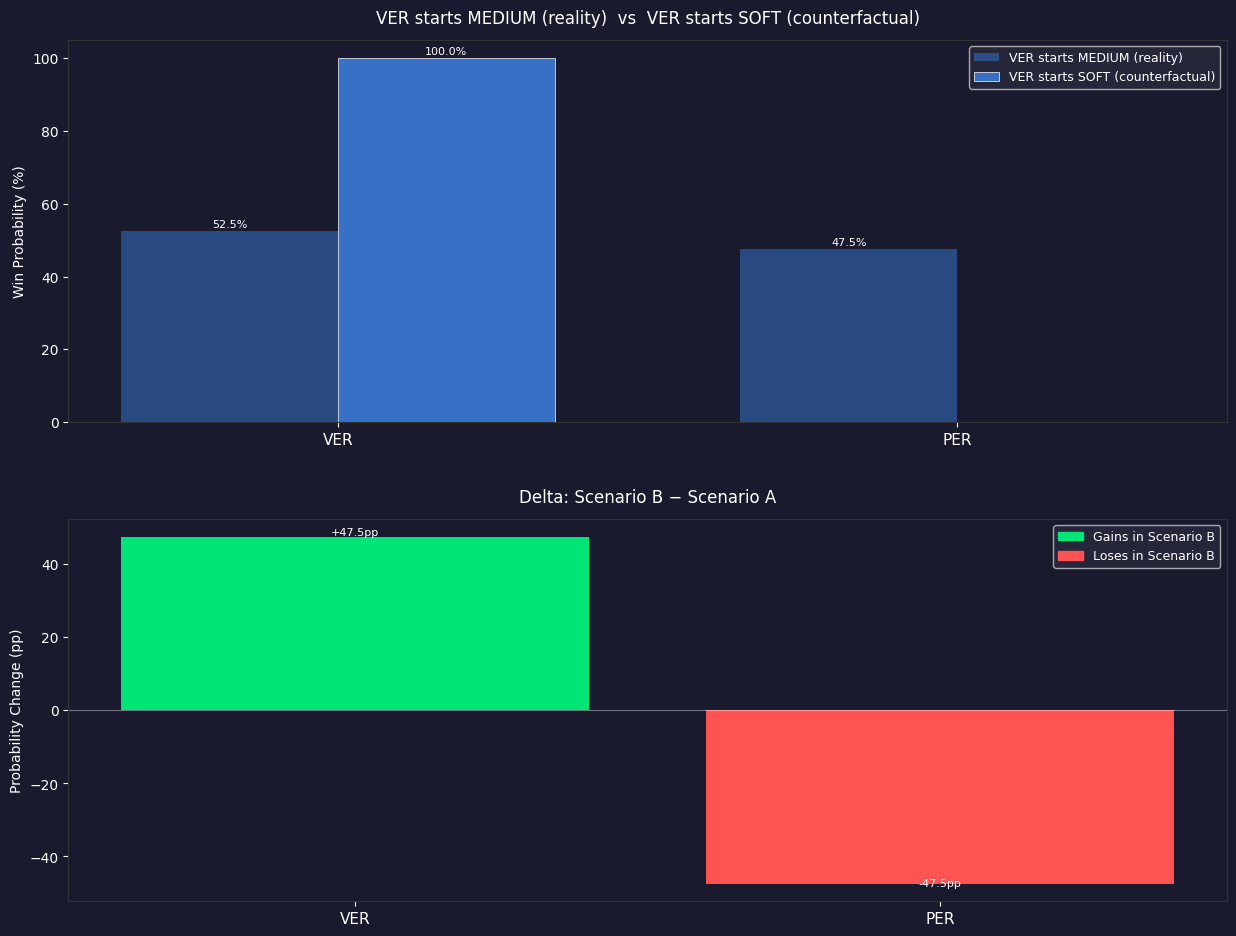

Saved to Drive


In [30]:
import matplotlib.patches as mpatches

TEAM_COLOURS = {
    'Red Bull Racing' : '#3671C6',
    'Ferrari'         : '#E8002D',
    'Mercedes'        : '#27F4D2',
    'McLaren'         : '#FF8000',
    'Aston Martin'    : '#358C75',
    'Alpine'          : '#FF87BC',
    'Williams'        : '#64C4FF',
    'RB'              : '#6692FF',
    'Kick Sauber'     : '#52E252',
    'Haas F1 Team'    : '#B6BABD',
}

def driver_colour(driver_code, grid):
    for entry in grid:
        if entry['driver'] == driver_code:
            return TEAM_COLOURS.get(entry['team'], '#888888')
    return '#888888'

# ── Ordered by Scenario A probability ────────────────────────────────────────
drivers_ordered = sorted(
    results['delta'].keys(),
    key=lambda d: results['probs_a'].get(d, 0),
    reverse=True
)

p_a_vals   = [results['probs_a'].get(d, 0) * 100 for d in drivers_ordered]
p_b_vals   = [results['probs_b'].get(d, 0) * 100 for d in drivers_ordered]
delta_vals = [results['delta'][d] * 100           for d in drivers_ordered]
colours    = [driver_colour(d, grid_a)             for d in drivers_ordered]

x     = np.arange(len(drivers_ordered))
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10), facecolor='#1a1a2e')

#  Top: side-by-side bars
ax1.set_facecolor('#1a1a2e')
bars_a = ax1.bar(x - width/2, p_a_vals, width, color=colours, alpha=0.55, label=LABEL_A)
bars_b = ax1.bar(x + width/2, p_b_vals, width, color=colours, alpha=1.0,  label=LABEL_B,
                 edgecolor='white', linewidth=0.5)

ax1.set_xticks(x)
ax1.set_xticklabels(drivers_ordered, color='white', fontsize=11)
ax1.set_ylabel('Win Probability (%)', color='white')
ax1.set_title(f'{LABEL_A}  vs  {LABEL_B}', color='white', fontsize=12, pad=12)
ax1.tick_params(colors='white')
ax1.spines[['top','right','left','bottom']].set_color('#333')
ax1.legend(facecolor='#2a2a3e', labelcolor='white', fontsize=9)

for bar in [*bars_a, *bars_b]:
    h = bar.get_height()
    if h > 1.5:
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.4,
                 f'{h:.1f}%', ha='center', va='bottom', color='white', fontsize=8)

#  Bottom: delta bars
ax2.set_facecolor('#1a1a2e')
delta_colours = ['#00e676' if d >= 0 else '#ff5252' for d in delta_vals]
bars_d = ax2.bar(x, delta_vals, color=delta_colours)

ax2.axhline(0, color='white', linewidth=0.8, alpha=0.4)
ax2.set_xticks(x)
ax2.set_xticklabels(drivers_ordered, color='white', fontsize=11)
ax2.set_ylabel('Probability Change (pp)', color='white')
ax2.set_title(f'Delta: Scenario B − Scenario A', color='white', fontsize=12, pad=12)
ax2.tick_params(colors='white')
ax2.spines[['top','right','left','bottom']].set_color('#333')

for bar, val in zip(bars_d, delta_vals):
    if abs(val) > 0.5:
        ax2.text(bar.get_x() + bar.get_width()/2,
                 val + (0.3 if val >= 0 else -0.7),
                 f'{val:+.1f}pp', ha='center', color='white', fontsize=8)

gain_patch = mpatches.Patch(color='#00e676', label='Gains in Scenario B')
loss_patch = mpatches.Patch(color='#ff5252', label='Loses in Scenario B')
ax2.legend(handles=[gain_patch, loss_patch], facecolor='#2a2a3e',
           labelcolor='white', fontsize=9)

plt.tight_layout(pad=3.0)
plt.savefig('/content/drive/MyDrive/f1_models/what_if_result.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Saved to Drive')